### Импортируем необходимые библиотеки

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

### Загружаем датасет и добавляем необходимые настройки отображения

In [56]:
path = '/Users/sergei/Desktop/start/Moscow_rent_dataset/Релиз 1/_data.csv'
df = pd.read_csv(path)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.tail(1)

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,Телефоны,Описание,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
23367,23367,274672243,"2, Оба варианта",Квартира,м. Говорово (10 мин пешком),"Москва, улица Богданова, 2к1, ш. Боровское (3 ...",90.0/48.2/15.5,"6/23, Панельный",NaN,"57000.0 руб./ За месяц, Залог - 60000 руб., Ко...",+79623641533,Сдается просторная двухкомнатная квартира ВПЕР...,Косметический,"26,2+15,5-22,0",Лоджия (1),Во двор,Раздельный (1),"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Сти...",NaN,NaN,NaN,Пасс (3),Да,https://www.cian.ru/rent/flat/274672243


### Изучаем названия столбцов

In [57]:
print(df.columns.tolist())

['Unnamed: 0', 'ID  объявления', 'Количество комнат', 'Тип', 'Метро', 'Адрес', 'Площадь, м2', 'Дом', 'Парковка', 'Цена', 'Телефоны', 'Описание', 'Ремонт', 'Площадь комнат, м2', 'Балкон', 'Окна', 'Санузел', 'Можно с детьми/животными', 'Дополнительно', 'Название ЖК', 'Серия дома', 'Высота потолков, м', 'Лифт', 'Мусоропровод', 'Ссылка на объявление']


### Создаем копию набора данных, которую будем чистить df_clean

In [58]:
df_cleaned = df.copy()

### Очищаем от дубликатов по ID, оставляя строки с наиболее заполненными строками

In [59]:
# Создаем колонку с количеством заполненных значений
df_cleaned['filled_count'] = df_cleaned.notna().sum(axis=1)

# Очищаем от дубликатов по ID, оставляя наиболее заполненные строки
df_cleaned = df_cleaned.sort_values('filled_count', ascending=False).drop_duplicates(subset=['ID  объявления'])

# Удаляем временную колонку
#df_cleaned = df_cleaned.drop('filled_count', axis=1)

print(f"Было: {len(df)} строк")
print(f"Стало: {len(df_cleaned)} строк")
print(f"Удалено дубликатов: {len(df) - len(df_cleaned)}")

Было: 23368 строк
Стало: 23368 строк
Удалено дубликатов: 0


в тестовой базе не было найдено дубликатов по ID объявления

### Проверяем заполненность строк (сколько пропусков у какого количества строк)

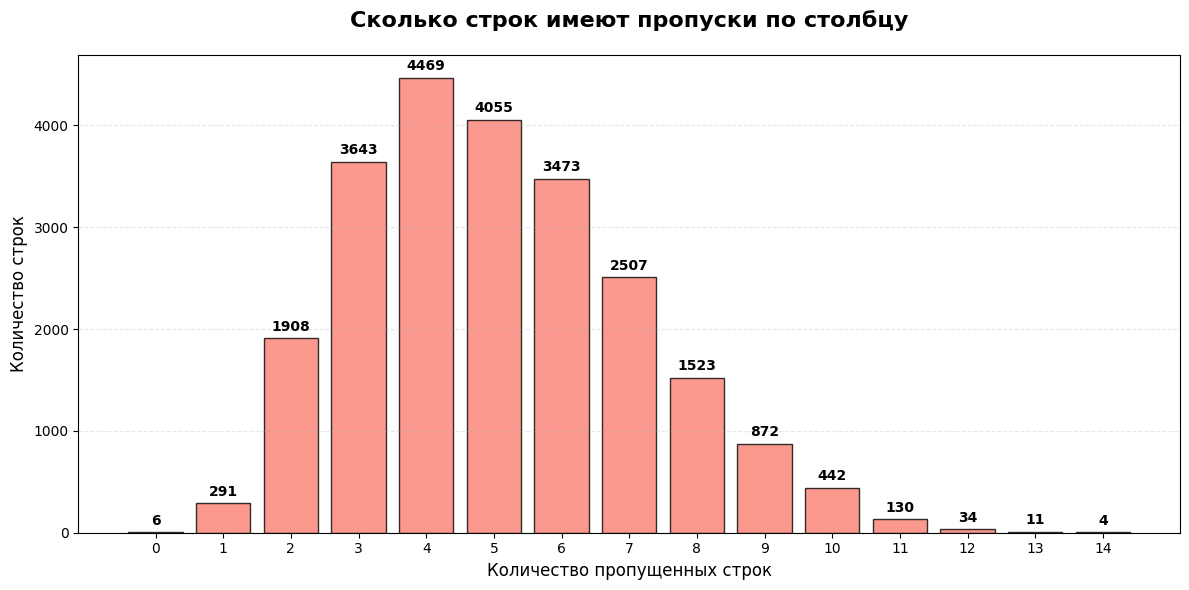

In [60]:
# Считаем, сколько пропусков (NaN) в каждой строке
df_cleaned['пропуски'] = df_cleaned.isnull().sum(axis=1)

# Смотрим, сколько строк с 0 пропусками, с 1, с 2 и т.д.
статистика = df_cleaned['пропуски'].value_counts().sort_index()

# Рисуем столбчатую диаграмму по количеству пропусков в столбцах
plt.figure(figsize=(12, 6))
plt.bar(статистика.index, статистика.values, color='salmon', edgecolor='black', alpha=0.8)
plt.title('Сколько строк имеют пропуски по столбцу', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Количество пропущенных строк', fontsize=12)
plt.ylabel('Количество строк', fontsize=12)
plt.xticks(range(статистика.index.min(), статистика.index.max() + 1))

# Подписываем точные цифры над каждым столбцом
for i, значение in enumerate(статистика.values):
    plt.text(i, значение + статистика.values.max()*0.01, str(значение), 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Удаляем строки с 9 и более пропусками 

In [62]:
# Сохраняем исходное количество строк
original_rows = len(df_cleaned)
print(f"Исходное количество строк: {original_rows}")

# Удаляем строки с более чем 8 пропусками
df_cleaned_1 = df_cleaned[df_cleaned['missing_count'] <= 8]

# Считаем результат
df_cleaned_rows = len(df_cleaned_1)
remaining_percentage = (df_cleaned_rows / original_rows) * 100

print(f"После удаления строк: {df_cleaned_rows}")
print(f"Осталось {remaining_percentage:.1f}% строк")#1 цифра после запятой
print(f"Удалено {original_rows - df_cleaned_rows} строк ({100 - remaining_percentage:.1f}%)")

Исходное количество строк: 23368


KeyError: 'missing_count'

### Проверяем гипотезу о том, что в колонке "Тип" все значения равны "Квартира"

In [63]:
type_counts = df_cleaned['Тип'].value_counts()
print("Уникальные значения в столбце 'Тип':")
print(type_counts)

Уникальные значения в столбце 'Тип':
Тип
Квартира    23368
Name: count, dtype: int64


### Удаляем указанные столбцы:
**Unnamed: 0** - дублирует индексы

**Тип** - имеет одинаковые значения 

**Телефоны** - не может влиять на цену

**Описание** - слишком разнородные данные сюда вписывают авторы объявлений  

**Ссылка на объявление** - не может влиять на цену

In [64]:
columns_to_drop = ['Unnamed: 0', 'Тип', 'Телефоны', 'Описание','Ссылка на объявление']
df_cleaned = df_cleaned_1.drop(columns=columns_to_drop)

print(f"Было столбцов: {len(df.columns)}")
print(f"Стало столбцов: {len(df_cleaned.columns)}")
print(f"Удаленные столбцы: {columns_to_drop}")

Было столбцов: 25
Стало столбцов: 23
Удаленные столбцы: ['Unnamed: 0', 'Тип', 'Телефоны', 'Описание', 'Ссылка на объявление']


### Определим сколько пропусков в каждой из оставшихся колонок

In [65]:
df_cleaned.isna().sum()

ID  объявления                  0
Количество комнат             797
Метро                         977
Адрес                           0
Площадь, м2                     0
Дом                             0
Парковка                    12013
Цена                            0
Ремонт                       2281
Площадь комнат, м2           7752
Балкон                       6825
Окна                         5401
Санузел                      1920
Можно с детьми/животными     5194
Дополнительно                 167
Название ЖК                 16295
Серия дома                  19779
Высота потолков, м          10754
Лифт                         4344
Мусоропровод                 9259
filled_count                    0
missing_count                   0
пропуски                        0
dtype: int64

### Проверим чем заполнен столбец 'Количество комнат'

In [66]:
nrooms_counts = df_cleaned['Количество комнат'].value_counts()
print("Уникальные значения в столбце 'Количество комнат':")
print(nrooms_counts)

Уникальные значения в столбце 'Количество комнат':
Количество комнат
1                   7487
2, Изолированная    4522
2                   2315
3                   1546
3, Изолированная    1540
3, Оба варианта      846
2, Смежная           609
4                    598
2, Оба варианта      582
4, Оба варианта      249
4, Изолированная     211
5                    207
3, Смежная            87
5, Оба варианта       81
6                     72
5, Изолированная      45
6, Оба варианта       31
6, Изолированная      17
4, Смежная            13
1, Изолированная       8
5, Смежная             4
6, Смежная             3
1, Оба варианта        3
1, Смежная             2
Name: count, dtype: int64


### Заполним пропуски в столбце "Количество комнат" значением "Свободная планировка"

In [67]:
df_cleaned['Количество комнат'] = df_cleaned['Количество комнат'].fillna('Свободная планировка')
print(df_cleaned['Количество комнат'].isna().sum())

0


### Разделим колонку "Количество комнат" на 2 колонки "Количество_комнат", "Описание_комнат". 

Пропуски в описании заполним значением "Обычная".

In [68]:
# Разделяем на количество комнат и описание
df_cleaned[['Количество_комнат', 'Описание_комнат']] = df_cleaned['Количество комнат'].str.split(', ', n=1, expand=True)
#expand=True - возвращает DataFrame вместо списка
#Каждая часть разделения становится отдельным столбцом

# Заполняем пропуски в описании
df_cleaned['Описание_комнат'] = df_cleaned['Описание_комнат'].fillna('Обычная')

# print("Результат разделения:")
# print(df_cleaned[['Количество комнат', 'Количество_комнат', 'Описание_комнат']].head(10))

# УДАЛЯЕМ НАЧАЛЬНУЮ КОЛОНКУ
df_cleaned = df_cleaned.drop('Количество комнат', axis=1)

print(f"\nКолонки после удаления:")
print([col for col in df_cleaned.columns if 'комнат' in col])


Колонки после удаления:
['Площадь комнат, м2', 'Количество_комнат', 'Описание_комнат']


### Проверим чем заполнен столбец 'Метро'

In [69]:
metro_counts = df_cleaned['Метро'].value_counts()
print("Уникальные значения в столбце 'Метро':")
print(metro_counts.tail(5))

Уникальные значения в столбце 'Метро':
Метро
м. Ломоносовская (4 мин пешком)         1
м. Рижская (14 мин пешком)              1
м. Студенческая (4 мин пешком)          1
м. Площадь Ленина (30 мин на машине)    1
м. Коптево (25 мин пешком)              1
Name: count, dtype: int64


### Разбиваем столбец "Метро" на 3 столбца - название станции, время до метро и тип транспорта

In [70]:
def extract_detailed_metro_info(metro_text):
    if pd.isna(metro_text):
        return pd.Series([None, None, None])
    
    # Название метро
    metro_name = metro_text.split('(')[0].strip()
    
    # Время и транспорт
    time_match = re.search(r'(\d+)\s*мин\s*(.*?)\)', metro_text)
    if time_match:
        time_minutes = int(time_match.group(1))
        transport_type = time_match.group(2).strip()
    else:
        time_minutes = None
        transport_type = None
    
    return pd.Series([metro_name, time_minutes, transport_type])

# Создаем три колонки
df_cleaned[['Название метро', 'Время_мин', 'Тип_транспорта']] = df_cleaned['Метро'].apply(extract_detailed_metro_info)
# УДАЛЯЕМ НАЧАЛЬНУЮ КОЛОНКУ
df_cleaned = df_cleaned.drop('Метро', axis=1)
print(df_cleaned[['Название метро', 'Время_мин', 'Тип_транспорта']].head())

                  Название метро  Время_мин Тип_транспорта
23082               м. Тушинская        6.0         пешком
11778  м. Преображенская площадь        9.0         пешком
15327             м. Новаторская       10.0         пешком
21944              м. Некрасовка       18.0         пешком
19340            м. Алексеевская        6.0         пешком


### Удаляем служебные колонки

In [71]:
df_cleaned = df_cleaned.drop('filled_count', axis=1)
df_cleaned = df_cleaned.drop('missing_count', axis=1)

### Проверяем количество пустых строк

In [72]:
print(df_cleaned['Название метро'].isna().sum())

977


### Взять все строки, где "Название метро" == NaN, определить по адресу с помощью OpenStreetMap 

In [ ]:
#Удалить пропуски из колонки "Название метро" (пока не сделано)

### Делим колонку "Площадь, м2 " на 3 колонки: "Общая площадь", "Жилая площадь", "Площадь кухни"

In [74]:
def split_area(area_text):
    """
    Разбивает площадь на три компонента с обработкой разных форматов
    """
    if pd.isna(area_text):
        return pd.Series([None, None, None])
    
    area_str = str(area_text).strip()
    
    # Разделяем по слешу
    parts = area_str.split('/')
    
    # Обрабатываем разное количество частей
    if len(parts) == 3:
        return pd.Series([parts[0].strip(), parts[1].strip(), parts[2].strip()])
    elif len(parts) == 2:
        return pd.Series([parts[0].strip(), parts[1].strip(), None])
    elif len(parts) == 1:
        return pd.Series([parts[0].strip(), None, None])
    else:
        return pd.Series([None, None, None])

# Применяем функцию
df_cleaned[['Общая_площадь', 'Жилая_площадь', 'Площадь_кухни']] = df_cleaned['Площадь, м2'].apply(split_area)

# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Площадь, м2', axis=1)

# Преобразуем в числа
area_columns = ['Общая_площадь', 'Жилая_площадь', 'Площадь_кухни']
for col in area_columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')# если текст, если запятая вместо точки, заменит на NaN

In [87]:
df_cleaned.head(3)

,ID объявления,Адрес,Дом,Парковка,Цена,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Количество_комнат,Описание_комнат,Название метро,Время_мин,Тип_транспорта,Общая_площадь,Жилая_площадь,Площадь_кухни
1315,252137540,"Москва, Муравская улица, 38к2","5/25, Монолитный",наземная,"40000.0 руб./ За месяц, Залог - 40000 руб., Ко...",Евроремонт,20,Балкон (1),На улицу,Совмещенный (1),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Душевая ка...","Мир Митино, 2019","2,84",2.80,"Пасс (1), Груз (1)",Да,1,Обычная,м. Пятницкое шоссе,15.0,пешком,40.0,20.0,10.0
21944,274789736,"Москва, улица Лавриненко, 13к3, ш. Новорязанск...","6/17, Монолитно-кирпичный",наземная,"40000.0 руб./ За месяц, Залог - 40000 руб., Ко...",Евроремонт,18-18,Лоджия (1),На улицу и двор,Совмещенный (1),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...","Некрасовка, 2019",ДомРик,2.64,Пасс (2),Да,2,Обычная,м. Некрасовка,18.0,пешком,56.0,36.0,9.0
15327,274376605,"Москва, Ленинский проспект, 105к3","14/25, Монолитный",подземная,"115000.0 руб./ За месяц, Залог - 115000 руб., ...",Евроремонт,20-18-22,Лоджия (1),Во двор,"Совмещенный (1), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...","Ленинский проспект 105к3, 2008",инд.,3.00,"Пасс (2), Груз (2)",Да,4,Изолированная,м. Новаторская,10.0,пешком,103.0,60.0,22.0


### Отследим и заполним пропуски в новых колонках

In [89]:
print(df_cleaned['Жилая_площадь'].isna().sum())

2579


In [93]:
nulls_before = df_cleaned['Жилая_площадь'].isnull().sum()

df_cleaned['Жилая_площадь'] = df_cleaned['Жилая_площадь'].fillna(df_cleaned['Общая_площадь'])

nulls_after = df_cleaned['Жилая_площадь'].isnull().sum()

print(f"Заполнено пропусков: {nulls_before - nulls_after}")
print(f"Осталось пропусков: {nulls_after}")

Заполнено пропусков: 2579
Осталось пропусков: 0


In [90]:
print(df_cleaned['Площадь_кухни'].isna().sum())

4751


In [92]:
# Вычисляем медиану площади кухни (игнорируя NaN)
kitchen_median = df_cleaned['Площадь_кухни'].median()

print(f"Медиана площади кухни: {kitchen_median}")

# Заменяем NaN на медиану
df_cleaned['Площадь_кухни'] = df_cleaned['Площадь_кухни'].fillna(kitchen_median)

print(f"Осталось {df_cleaned['Площадь_кухни'].isnull().sum()} пропусков")

Медиана площади кухни: 9.0
Осталось 0 пропусков


Разделим колонку "Дом" на 3 колонки: "Этаж", "Всего этажей", "Тип_дома"

In [94]:
# Разделяем на этажи и тип дома
df_cleaned[['Этажи', 'Тип_дома']] = df_cleaned['Дом'].str.split(', ', n=1, expand=True)

# Разделяем этажи на текущий и всего
df_cleaned[['Этаж', 'Всего_этажей']] = df_cleaned['Этажи'].str.split('/', expand=True)

# Удаляем временную колонку
df_cleaned = df_cleaned.drop('Этажи', axis=1)
# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Дом', axis=1)
print("Результат разделения:")
print(df_cleaned[['Этаж', 'Всего_этажей', 'Тип_дома']].head(10))

Результат разделения:
      Этаж Всего_этажей             Тип_дома
1315     5           25           Монолитный
21944    6           17  Монолитно-кирпичный
15327   14           25           Монолитный
19340   17           17            Панельный
11778    5           18           Монолитный
23082    5            9           Монолитный
7043    17           17            Панельный
17698    3           17           Монолитный
8262    10           19           Монолитный
15464    6           10            Панельный


In [95]:
print(df_cleaned['Этаж'].isnull().sum())
print(df_cleaned['Всего_этажей'].isnull().sum())
print(df_cleaned['Тип_дома'].isnull().sum())

0
0
3387


In [ ]:
#заполним пропуске в колонке "Тип_дома" модой этой колонки
house_type_mode = df_cleaned['Тип_дома'].mode()[0]  # мода возвращает series берем первый элемент
print(f"Мода: {house_type_mode}")

df_cleaned['Тип_дома'] = df_cleaned['Тип_дома'].fillna(house_type_mode)
print(df_cleaned['Тип_дома'].isnull().sum())

Мода: Панельный
0


Парковка

In [100]:
# Уникальные значения с количеством
parking = df_cleaned['Парковка'].value_counts()
print("Уникальные значения в столбце 'Парковка':")
print(parking)
print(df_cleaned['Парковка'].isnull().sum())

Уникальные значения в столбце 'Парковка':
Парковка
наземная          5980
подземная         2755
открытая          1009
многоуровневая     117
на крыше             1
Name: count, dtype: int64
12013


In [103]:
#Объединим парковку в 2 типа Бесплатная = наземная + открытая + NaN, Платная = подземная, многоуровневая, на крыше
# Анализ исходных данных
# print("Исходное распределение парковки:")
# original_counts = df_cleaned['Парковка'].value_counts(dropna=False)
# print(original_counts)

# Создаем mapping для объединения
parking_mapping = {
    'наземная': 'Бесплатная',
    'открытая': 'Бесплатная', 
    'подземная': 'Платная',
    'многоуровневая': 'Платная',
    'на крыше': 'Платная'
}

# Заменяем значения
df_cleaned['Парковка_тип'] = df_cleaned['Парковка'].map(parking_mapping)

# Заполняем оставшиеся NaN и неизвестные значения как 'Бесплатная'
df_cleaned['Парковка_тип'] = df_cleaned['Парковка_тип'].fillna('Бесплатная')
# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Парковка', axis=1)
print("\nПосле объединения:")
print(df_cleaned['Парковка_тип'].value_counts())


После объединения:
Парковка_тип
Бесплатная    19002
Платная        2873
Name: count, dtype: int64


In [104]:
df_cleaned.head()

,ID объявления,Адрес,Цена,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Количество_комнат,Описание_комнат,Название метро,Время_мин,Тип_транспорта,Общая_площадь,Жилая_площадь,Площадь_кухни,Тип_дома,Этаж,Всего_этажей,Парковка_тип
1315,252137540,"Москва, Муравская улица, 38к2","40000.0 руб./ За месяц, Залог - 40000 руб., Ко...",Евроремонт,20,Балкон (1),На улицу,Совмещенный (1),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Душевая ка...","Мир Митино, 2019","2,84",2.80,"Пасс (1), Груз (1)",Да,1,Обычная,м. Пятницкое шоссе,15.0,пешком,40.0,20.0,10.0,Монолитный,5,25,Бесплатная
21944,274789736,"Москва, улица Лавриненко, 13к3, ш. Новорязанск...","40000.0 руб./ За месяц, Залог - 40000 руб., Ко...",Евроремонт,18-18,Лоджия (1),На улицу и двор,Совмещенный (1),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...","Некрасовка, 2019",ДомРик,2.64,Пасс (2),Да,2,Обычная,м. Некрасовка,18.0,пешком,56.0,36.0,9.0,Монолитно-кирпичный,6,17,Бесплатная
15327,274376605,"Москва, Ленинский проспект, 105к3","115000.0 руб./ За месяц, Залог - 115000 руб., ...",Евроремонт,20-18-22,Лоджия (1),Во двор,"Совмещенный (1), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...","Ленинский проспект 105к3, 2008",инд.,3.00,"Пасс (2), Груз (2)",Да,4,Изолированная,м. Новаторская,10.0,пешком,103.0,60.0,22.0,Монолитный,14,25,Платная
19340,274473158,"Москва, 3-я Мытищинская улица, 3к1","80000.0 руб./ За месяц, Залог - 80000 руб., Ко...",Косметический,20-15-11,Балкон (1),Во двор,Раздельный (1),"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Сти...","Алексеево, 2010",П-44т,2.70,"Пасс (2), Груз (1)",Да,3,Обычная,м. Алексеевская,6.0,пешком,75.0,46.0,13.0,Панельный,17,17,Бесплатная
11778,243160784,"Москва, Краснобогатырская улица, 90С2","80000.0 руб./ За месяц, Залог - 80000 руб., Ко...",Косметический,20-15,Лоджия (1),Во двор,Совмещенный (1),"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Душевая ка...","Наследие, 2017",Инд.проект,3.10,"Пасс (1), Груз (1)",Да,2,Смежная,м. Преображенская площадь,9.0,пешком,53.0,35.0,8.0,Монолитный,5,18,Платная


In [105]:
print(df_cleaned['Цена'].value_counts())

Цена
40000.0 руб./ За месяц, Залог - 40000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предоплата 1 мес                                                         1069
45000.0 руб./ За месяц, Залог - 45000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предоплата 1 мес                                                         1028
35000.0 руб./ За месяц, Залог - 35000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предоплата 1 мес                                                          922
50000.0 руб./ За месяц, Залог - 50000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предоплата 1 мес                                                          868
55000.0 руб./ За месяц, Залог - 55000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предоплата 1 мес                                                          662
60000.0 руб./ За месяц, Залог - 60000 руб., Коммунальные услуги включены, Срок аренды - Длительный, Предо

In [110]:
# Извлекаем только числовую цену из текста
def extract_numeric_price(price_text):
    """
    Извлекает числовую цену из текстового описания
    """
    if pd.isna(price_text):
        return None
    
    try:
        # Ищем первое число в тексте (это цена за месяц)
        match = re.search(r'(\d+\.?\d*)', str(price_text))
        if match:
            return float(match.group(1))
        else:
            return None
    except:
        return None

# Создаем колонку с числовой ценой
df_cleaned['Цена_число'] = df_cleaned['Цена'].apply(extract_numeric_price)

print("Извлечение числовой цены:")
print(f"Успешно извлечено: {df_cleaned['Цена_число'].notna().sum()} из {len(df_cleaned)}")
print(df_cleaned[['Цена', 'Цена_число', 'Валюта']].head(10))

Извлечение числовой цены:
Успешно извлечено: 21875 из 21875
                                                    Цена  Цена_число Валюта
1315   40000.0 руб./ За месяц, Залог - 40000 руб., Ко...     40000.0   руб.
21944  40000.0 руб./ За месяц, Залог - 40000 руб., Ко...     40000.0   руб.
15327  115000.0 руб./ За месяц, Залог - 115000 руб., ...    115000.0   руб.
19340  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.
11778  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.
23082  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.
7043   60000.0 руб./ За месяц, Залог - 60000 руб., Ко...     60000.0   руб.
17698  180000.0 руб./ За месяц, Залог - 180000 руб., ...    180000.0   руб.
8262   45000.0 руб./ За месяц, Залог - 45000 руб., Ко...     45000.0   руб.
15464  21000.0 руб./ За месяц, Залог - 21000 руб., Ср...     21000.0   руб.


In [111]:
# Курсы валют (примерные, замените на актуальные)
USD_RATE = 80.94  # курс доллара
EUR_RATE = 93.94  # курс евро

def convert_to_rubles(price, currency):
    """
    Конвертирует цену в рубли по курсу
    """
    if pd.isna(price) or pd.isna(currency):
        return None
    
    try:
        currency = str(currency).lower().strip()
        
        if currency in ['usd', '$', 'доллар']:
            return price * USD_RATE
        elif currency in ['eur', '€', 'евро']:
            return price * EUR_RATE
        elif currency in ['руб.', 'rub', 'рубль']:
            return price
        else:
            return price  # по умолчанию считаем рублями
    except:
        return None

# Конвертируем в рубли
df_cleaned['Цена_в_рублях'] = df_cleaned.apply(
    lambda row: convert_to_rubles(row['Цена_число'], row['Валюта']), 
    axis=1
)

print("Результат конвертации:")
print(df_cleaned[['Цена', 'Цена_число', 'Валюта', 'Цена_в_рублях']].head(10))

Результат конвертации:
                                                    Цена  Цена_число Валюта  \
1315   40000.0 руб./ За месяц, Залог - 40000 руб., Ко...     40000.0   руб.   
21944  40000.0 руб./ За месяц, Залог - 40000 руб., Ко...     40000.0   руб.   
15327  115000.0 руб./ За месяц, Залог - 115000 руб., ...    115000.0   руб.   
19340  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.   
11778  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.   
23082  80000.0 руб./ За месяц, Залог - 80000 руб., Ко...     80000.0   руб.   
7043   60000.0 руб./ За месяц, Залог - 60000 руб., Ко...     60000.0   руб.   
17698  180000.0 руб./ За месяц, Залог - 180000 руб., ...    180000.0   руб.   
8262   45000.0 руб./ За месяц, Залог - 45000 руб., Ко...     45000.0   руб.   
15464  21000.0 руб./ За месяц, Залог - 21000 руб., Ср...     21000.0   руб.   

       Цена_в_рублях  
1315         40000.0  
21944        40000.0  
15327       115000.0  
19340        80

In [112]:
# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Цена', axis=1)

In [115]:
df_cleaned.head()

,ID объявления,Адрес,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Количество_комнат,Описание_комнат,Название метро,Время_мин,Тип_транспорта,Общая_площадь,Жилая_площадь,Площадь_кухни,Тип_дома,Этаж,Всего_этажей,Парковка_тип,Цена_число,Валюта,Цена_в_рублях
1315,252137540,"Москва, Муравская улица, 38к2",Евроремонт,20,Балкон (1),На улицу,Совмещенный (1),"2,84",2.80,"Пасс (1), Груз (1)",Да,1,Обычная,м. Пятницкое шоссе,15.0,пешком,40.0,20.0,10.0,Монолитный,5,25,Бесплатная,40000.0,руб.,40000.0
21944,274789736,"Москва, улица Лавриненко, 13к3, ш. Новорязанск...",Евроремонт,18-18,Лоджия (1),На улицу и двор,Совмещенный (1),ДомРик,2.64,Пасс (2),Да,2,Обычная,м. Некрасовка,18.0,пешком,56.0,36.0,9.0,Монолитно-кирпичный,6,17,Бесплатная,40000.0,руб.,40000.0
15327,274376605,"Москва, Ленинский проспект, 105к3",Евроремонт,20-18-22,Лоджия (1),Во двор,"Совмещенный (1), Раздельный (1)",инд.,3.00,"Пасс (2), Груз (2)",Да,4,Изолированная,м. Новаторская,10.0,пешком,103.0,60.0,22.0,Монолитный,14,25,Платная,115000.0,руб.,115000.0
19340,274473158,"Москва, 3-я Мытищинская улица, 3к1",Косметический,20-15-11,Балкон (1),Во двор,Раздельный (1),П-44т,2.70,"Пасс (2), Груз (1)",Да,3,Обычная,м. Алексеевская,6.0,пешком,75.0,46.0,13.0,Панельный,17,17,Бесплатная,80000.0,руб.,80000.0
11778,243160784,"Москва, Краснобогатырская улица, 90С2",Косметический,20-15,Лоджия (1),Во двор,Совмещенный (1),Инд.проект,3.10,"Пасс (1), Груз (1)",Да,2,Смежная,м. Преображенская площадь,9.0,пешком,53.0,35.0,8.0,Монолитный,5,18,Платная,80000.0,руб.,80000.0


In [114]:
df_cleaned = df_cleaned.drop('Можно с детьми/животными', axis=1)
df_cleaned = df_cleaned.drop('Дополнительно', axis=1)
df_cleaned = df_cleaned.drop('Название ЖК', axis=1)


In [117]:
print(df_cleaned['Ремонт'].value_counts())
print(df_cleaned['Ремонт'].isnull().sum())

Ремонт
Косметический    8132
Евроремонт       8107
Дизайнерский     3209
Без ремонта       146
Name: count, dtype: int64
2281


In [119]:
df_cleaned['Ремонт'] = df_cleaned['Ремонт'].fillna('Без ремонта')
print(df_cleaned['Ремонт'].value_counts())

Ремонт
Косметический    8132
Евроремонт       8107
Дизайнерский     3209
Без ремонта      2427
Name: count, dtype: int64


Площадь комнат (возможно надо уточнить жилую площадь по этой колонке)

In [ ]:
#Сложить площадь комнат

Балкон

In [121]:
print(df_cleaned['Балкон'].value_counts())
print(df_cleaned['Ремонт'].isnull().sum())

Балкон
Балкон (1)                7199
Лоджия (1)                5925
Балкон (1), Лоджия (1)     710
Лоджия (2)                 562
Балкон (2)                 459
Балкон (3)                  53
Лоджия (3)                  45
Балкон (2), Лоджия (2)      25
Балкон (1), Лоджия (2)      24
Балкон (2), Лоджия (1)      20
Балкон (4)                   6
Лоджия (4)                   5
Балкон (3), Лоджия (1)       5
Балкон (1), Лоджия (3)       5
Балкон (2), Лоджия (3)       3
Балкон (1), Лоджия (4)       2
Балкон (4), Лоджия (4)       1
Балкон (3), Лоджия (3)       1
Name: count, dtype: int64
0


In [127]:
def extract_balcony_loggia(balcony_text):
    """
    Извлекает информацию о наличии балкона и лоджии
    """
    if pd.isna(balcony_text):
        return pd.Series([0, 0])
    
    text = str(balcony_text).lower()
    
    has_balcony = 1 if 'балкон' in text else 0
    has_loggia = 1 if 'лоджия' in text else 0
    
    return pd.Series([has_balcony, has_loggia])

# Применяем функцию
df_cleaned[['Балкон', 'Лоджия']] = df_cleaned['Балкон'].apply(extract_balcony_loggia)


In [142]:
df_cleaned.head(5)

,ID объявления,Адрес,Ремонт,"Площадь комнат, м2",Балкон,Окна,"Высота потолков, м",Лифт,Мусоропровод,Количество_комнат,Описание_комнат,Название метро,Время_мин,Тип_транспорта,Общая_площадь,Жилая_площадь,Площадь_кухни,Тип_дома,Этаж,Всего_этажей,Парковка_тип,Цена_число,Валюта,Цена_в_рублях,Лоджия,Санузел_раздельный,Санузел_совмещенный
1315,252137540,"Москва, Муравская улица, 38к2",Евроремонт,20,0,На улицу,2.80,"Пасс (1), Груз (1)",Да,1,Обычная,м. Пятницкое шоссе,15.0,пешком,40.0,20.0,10.0,Монолитный,5,25,Бесплатная,40000.0,руб.,40000.0,0,0,1
21944,274789736,"Москва, улица Лавриненко, 13к3, ш. Новорязанск...",Евроремонт,18-18,0,На улицу и двор,2.64,Пасс (2),Да,2,Обычная,м. Некрасовка,18.0,пешком,56.0,36.0,9.0,Монолитно-кирпичный,6,17,Бесплатная,40000.0,руб.,40000.0,0,0,1
15327,274376605,"Москва, Ленинский проспект, 105к3",Евроремонт,20-18-22,0,Во двор,3.00,"Пасс (2), Груз (2)",Да,4,Изолированная,м. Новаторская,10.0,пешком,103.0,60.0,22.0,Монолитный,14,25,Платная,115000.0,руб.,115000.0,0,1,1
19340,274473158,"Москва, 3-я Мытищинская улица, 3к1",Косметический,20-15-11,0,Во двор,2.70,"Пасс (2), Груз (1)",Да,3,Обычная,м. Алексеевская,6.0,пешком,75.0,46.0,13.0,Панельный,17,17,Бесплатная,80000.0,руб.,80000.0,0,1,0
11778,243160784,"Москва, Краснобогатырская улица, 90С2",Косметический,20-15,0,Во двор,3.10,"Пасс (1), Груз (1)",Да,2,Смежная,м. Преображенская площадь,9.0,пешком,53.0,35.0,8.0,Монолитный,5,18,Платная,80000.0,руб.,80000.0,0,0,1


Окна

In [128]:
print(df_cleaned['Окна'].value_counts())
print(df_cleaned['Ремонт'].isnull().sum())

Окна
Во двор            10685
На улицу и двор     3244
На улицу            2545
Name: count, dtype: int64
0


In [ ]:
#Пока оставляю

Санузел	

In [129]:
print(df_cleaned['Санузел'].value_counts())
print(df_cleaned['Санузел'].isnull().sum())

Санузел
Совмещенный (1)                    9637
Раздельный (1)                     6920
Совмещенный (2)                    1415
Совмещенный (1), Раздельный (1)     805
Раздельный (2)                      522
Совмещенный (3)                     235
Совмещенный (2), Раздельный (1)     182
Совмещенный (4)                      72
Раздельный (3)                       50
Совмещенный (1), Раздельный (2)      30
Совмещенный (3), Раздельный (1)      27
Совмещенный (2), Раздельный (2)      24
Раздельный (4)                       15
Совмещенный (4), Раздельный (1)       6
Совмещенный (3), Раздельный (3)       5
Совмещенный (4), Раздельный (2)       4
Совмещенный (2), Раздельный (3)       2
Совмещенный (1), Раздельный (3)       2
Совмещенный (3), Раздельный (2)       1
Совмещенный (2), Раздельный (4)       1
Name: count, dtype: int64
1920


In [130]:
def extract_bathroom_type(bathroom_text):
    """
    Извлекает информацию о типе санузла
    """
    if pd.isna(bathroom_text):
        return pd.Series([0, 0])
    
    text = str(bathroom_text)
    
    has_separate = 1 if 'Раздельный' in text else 0
    has_combined = 1 if 'Совмещенный' in text else 0
    
    return pd.Series([has_separate, has_combined])

# Применяем функцию
df_cleaned[['Санузел_раздельный', 'Санузел_совмещенный']] = df_cleaned['Санузел'].apply(extract_bathroom_type)

print("Результат:")
print(df_cleaned[['Санузел', 'Санузел_раздельный', 'Санузел_совмещенный']].head(10))

Результат:
                               Санузел  Санузел_раздельный  \
1315                   Совмещенный (1)                   0   
21944                  Совмещенный (1)                   0   
15327  Совмещенный (1), Раздельный (1)                   1   
19340                   Раздельный (1)                   1   
11778                  Совмещенный (1)                   0   
23082                  Совмещенный (1)                   0   
7043                    Раздельный (1)                   1   
17698                  Совмещенный (1)                   0   
8262                    Раздельный (1)                   1   
15464                   Раздельный (1)                   1   

       Санузел_совмещенный  
1315                     1  
21944                    1  
15327                    1  
19340                    0  
11778                    1  
23082                    1  
7043                     0  
17698                    1  
8262                     0  
15464           

In [131]:
# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Санузел', axis=1)

Серия дома

In [133]:
print(df_cleaned['Серия дома'].value_counts())
print(df_cleaned['Серия дома'].isnull().sum())

Серия дома
индивидуальный проект                                 601
Индивидуальный проект                                 138
П44                                                    85
П44Т                                                   60
монолит                                                38
СЭМ-2                                                  32
II-29                                                  27
П-44                                                   23
КОПЭ                                                   22
И-209А                                                 21
Кирпичный                                              19
I-511 (модификация I-511/25БИ)                         19
П-44Т                                                  18
СМ-6                                                   18
I-515/9ЮЛ                                              16
П3М                                                    16
I-515/9М                                               16
ПИК

Очень много пропусков, просто удаляем

In [134]:
# УДАЛЯЕМ НАЧАЛЬНЫЙ СТОЛБЕЦ
df_cleaned = df_cleaned.drop('Серия дома', axis=1)

Высота потолков 

In [136]:
print(df_cleaned['Высота потолков, м'].value_counts())
print(df_cleaned['Высота потолков, м'].isnull().sum())

Высота потолков, м
2.64      4442
3.00      1312
2.70      1036
2.48       666
3.20       614
2.60       534
2.80       532
2.50       454
2.75       221
3.10       164
2.65       153
2.74       150
2.90       141
3.50        72
2.77        63
3.30        59
2.85        53
4.00        53
2.95        48
3.40        32
2.78        30
2.55        28
2.40        27
3.60        27
3.80        18
3.70        14
5.00        13
3.15        10
2.54         8
4.20         7
6.00         7
3.05         7
2.66         7
2.58         6
4.50         5
2.67         5
4.60         5
2.84         4
3.25         4
2.56         4
27.00        4
2.00         3
2.30         3
2.63         3
2.72         3
3.90         3
28.00        3
3.35         3
4.10         3
3.11         2
5.80         2
264.00       2
2.68         2
2.51         2
2.57         2
5.50         2
2.87         2
320.00       2
2.73         2
2.76         2
2.20         2
2.45         2
2.88         1
2.86         1
2.99         1
25.00 

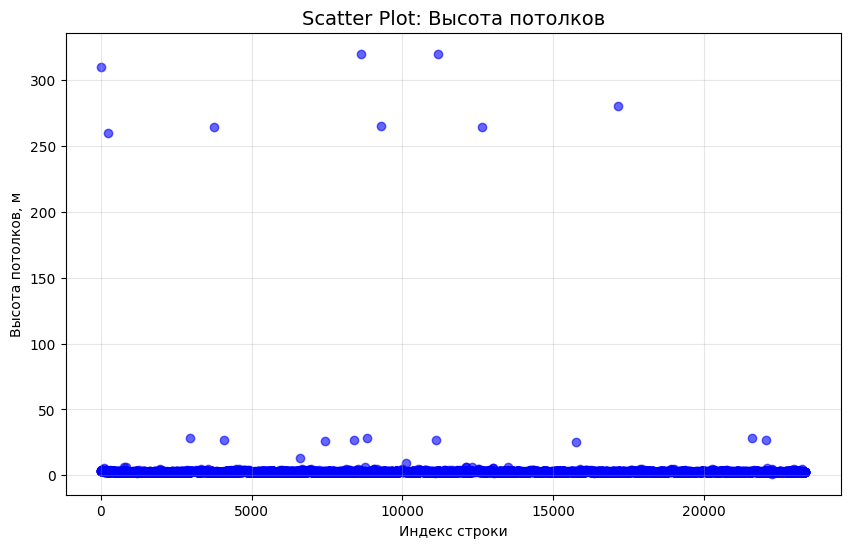

In [137]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned.index, df_cleaned['Высота потолков, м'], alpha=0.6, color='blue')
plt.title('Scatter Plot: Высота потолков', fontsize=14)
plt.xlabel('Индекс строки')
plt.ylabel('Высота потолков, м')
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
# Преобразуем значения больше 250 (см) в метры и заполняем пропуски
def correct_ceiling_height(height):
    """
    Исправляет высоту потолков: 
    - если > 250 см, преобразует в метры
    - если пропуск, заполняет значением 2.5 м
    """
    if pd.isna(height):
        return 2.5  # ЗАПОЛНЯЕМ ПРОПУСКИ ЗНАЧЕНИЕМ 2.5 МЕТРА
    
    try:
        height_num = float(height)
        if height_num > 250:  # если значение больше 250, вероятно это сантиметры
            return height_num / 100  # преобразуем в метры
        else:
            return height_num
    except:
        return 2.5  # в случае ошибки тоже возвращаем 2.5

# Применяем преобразование
df_cleaned['Высота потолков, м'] = df_cleaned['Высота потолков, м'].apply(correct_ceiling_height)

print("Результат преобразования:")
print(df_cleaned['Высота потолков, м'].describe())

Результат преобразования:
count    21875.000000
mean         2.643279
std          0.554017
min          1.200000
25%          2.500000
50%          2.500000
75%          2.640000
max         28.000000
Name: Высота потолков, м, dtype: float64


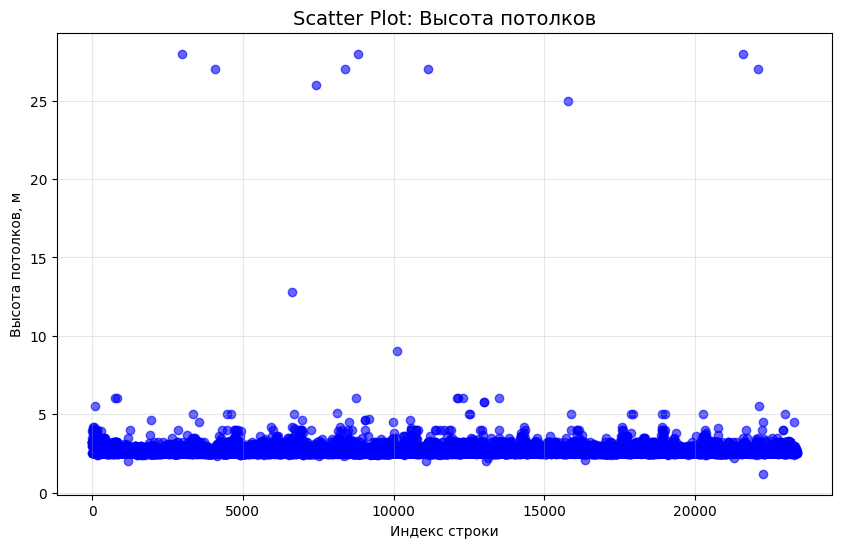

In [139]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned.index, df_cleaned['Высота потолков, м'], alpha=0.6, color='blue')
plt.title('Scatter Plot: Высота потолков', fontsize=14)
plt.xlabel('Индекс строки')
plt.ylabel('Высота потолков, м')
plt.grid(True, alpha=0.3)
plt.show()

In [140]:
df_cleaned['Высота потолков, м'] = df_cleaned['Высота потолков, м'].apply(
    lambda x: (
        2.5 if pd.isna(x) else
        (float(x) / 10 if float(x) >= 25 else
         (float(x) / 100 if float(x) > 250 else float(x)))
    ) if isinstance(x, (int, float, str)) and str(x).replace('.', '').isdigit() else 2.5
)

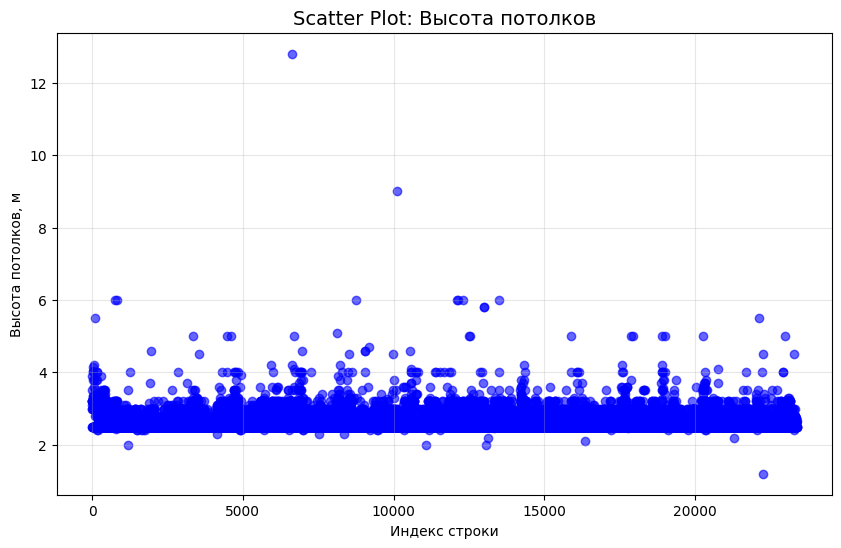

In [141]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned.index, df_cleaned['Высота потолков, м'], alpha=0.6, color='blue')
plt.title('Scatter Plot: Высота потолков', fontsize=14)
plt.xlabel('Индекс строки')
plt.ylabel('Высота потолков, м')
plt.grid(True, alpha=0.3)
plt.show()

Лифт

In [144]:
print(df_cleaned['Лифт'].value_counts())
print(df_cleaned['Лифт'].isnull().sum())

Лифт
Пасс (1)               5744
Пасс (2)               4274
Пасс (1), Груз (1)     3903
Пасс (2), Груз (1)     1209
Пасс (2), Груз (2)      649
Пасс (3)                626
Пасс (4)                333
Пасс (1), Груз (2)      185
Пасс (3), Груз (1)      184
Груз (1)                 91
Пасс (4), Груз (2)       64
Пасс (4), Груз (1)       62
Пасс (3), Груз (2)       44
Пасс (3), Груз (3)       42
Пасс (4), Груз (4)       26
Груз (4)                 24
Груз (2)                 20
Груз (3)                 15
Пасс (4), Груз (3)        7
Пасс (1), Груз (3)        6
Пасс (6)                  6
Пасс (2), Груз (3)        3
Пасс (50)                 2
Пасс (60)                 2
Груз (8)                  1
Пасс (5)                  1
Груз (6)                  1
Пасс (5), Груз (1)        1
Пасс (8), Груз (8)        1
Пасс (7)                  1
Пасс (1), Груз (4)        1
Пасс (2), Груз (4)        1
Пасс (1), Груз (12)       1
Пасс (5), Груз (3)        1
Name: count, dtype: int64
4344


In [75]:
def extract_elevator_types(elevator_text, total_floors=None):
    """
    Извлекает информацию о типах лифтов
    """
    # Преобразуем этажность в число, если она не None
    if total_floors is not None:
        try:
            total_floors = float(total_floors)
        except (ValueError, TypeError):
            total_floors = None
    
    # Обрабатываем пропуски
    if pd.isna(elevator_text) or elevator_text == '':
        if total_floors is not None and total_floors <= 5:
            return pd.Series([0, 0])  # до 5 этажей - лифта нет
        elif total_floors is not None and total_floors > 5:
            return pd.Series([1, 0])  # больше 5 этажей - пассажирский лифт
        else:
            return pd.Series([0, 0])  # если этажность неизвестна
    
    # Обрабатываем текст
    text = str(elevator_text)
    
    # Ищем пассажирские лифты
    has_passenger = 1 if 'Пасс' in text else 0
    
    # Ищем грузовые лифты
    has_cargo = 1 if 'Груз' in text else 0
    
    return pd.Series([has_passenger, has_cargo])

# Применяем функцию
df_cleaned[['Лифт_пассажирский', 'Лифт_грузовой']] = df_cleaned.apply(
    lambda row: extract_elevator_types(row['Лифт'], row['Всего_этажей']), 
    axis=1
)

print("Результат:")
print(df_cleaned[['Лифт', 'Всего_этажей', 'Лифт_пассажирский', 'Лифт_грузовой']].head(10))

KeyError: 'Всего_этажей'

Мусоропровод


In [147]:
print(df_cleaned['Мусоропровод'].value_counts())
print(df_cleaned['Мусоропровод'].isnull().sum())

Мусоропровод
Да     10811
Нет     1805
Name: count, dtype: int64
9259


### Пропуски заполняем как нет

In [ ]:
df_cleaned['Мусоропровод'] = df_cleaned['Мусоропровод'].fillna('Нет')

In [150]:
df_cleaned.isnull().sum()

ID  объявления            0
Адрес                     0
Ремонт                    0
Площадь комнат, м2     7752
Балкон                    0
Окна                   5401
Высота потолков, м        0
Лифт                   4344
Мусоропровод              0
Количество_комнат         0
Описание_комнат           0
Название метро          977
Время_мин              1856
Тип_транспорта         1856
Общая_площадь             0
Жилая_площадь             0
Площадь_кухни             0
Тип_дома                  0
Этаж                      0
Всего_этажей              0
Парковка_тип              0
Цена_число                0
Валюта                    0
Цена_в_рублях             0
Лоджия                    0
Санузел_раздельный        0
Санузел_совмещенный       0
Лифт_пассажирский         0
Лифт_грузовой             0
dtype: int64

In [77]:
df_cleaned.to_csv('data(1).csv', index=False)